# 07 Rational Guassian Hill

Building on previous notebooks in this notebook I try and use a rational quadractic hill as describived at (3.15 in the disseration)
$$
c(\gamma(s)) = 
c_0+
\frac{H R^2}
{R^2+\left|\gamma(s)-p\right|^2}.
$$

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("../src")
from terrain.terrain import Terrain
from geometry.endpoints import Endpoints
from geometry.path import Path
from geometry.generators import straight_line_path


### terrain ### 
terrain = Terrain(
    width=100,
    height=100,
    resolution=100,
    cost=0.1
)


terrain.add_quadratic_hill(
    centre=(50, 50),
    H=100,
    R=15
)


### boundarys ###

boundary = Endpoints(
    start=(10, 20),
    end=(80, 80)
)

boundary_df = boundary.to_dataframe()


terrain.grid.shape
terrain_df = terrain.to_dataframe()

### Initial Path
initial_path = straight_line_path(
    start=boundary.start,
    end=boundary.end,
    num_points=100
)

initial_path_df = initial_path.to_dataframe()

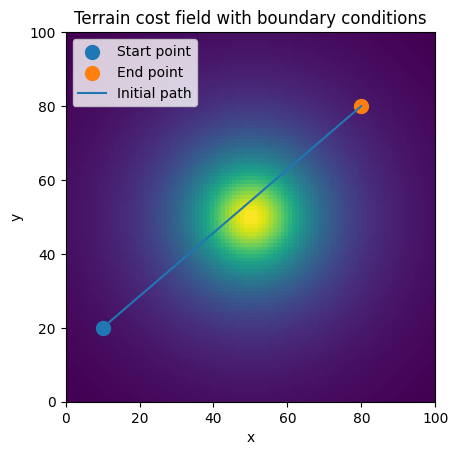

In [2]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot( 
    initial_path_df["x"],
    initial_path_df["y"],
    label="Initial path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

In [3]:
from cost_functions.terrain_cost import terrain_cost, terrain_curvature_cost, terrain_length_cost




print(terrain_cost(initial_path, terrain))
print(terrain_curvature_cost(initial_path))
print(terrain_length_cost(initial_path))


3667.5027231537993
1.555318160733747e-26
92.19544457292892


In [4]:

from optimisation.moves import shift_move, segment_shift_move

new_path = segment_shift_move(
            initial_path,
            terrain,
            sigma=2,
            alpha=10,
            segment_length=5
        )

print(

    terrain_length_cost(initial_path),

    terrain_length_cost(new_path)

)

print(

    np.array_equal(

        initial_path.points,

        new_path.points

    )

)

92.19544457292892 94.2321556439362
False


In [5]:
from optimisation.annealing import simulated_segment_annealing_curvature


best_path_segment, best_cost_segment, history_segment, path_history_segment = simulated_segment_annealing_curvature(
    initial_path=initial_path,
    terrain=terrain,
    iterations=10000,
    initial_temperature=500,
    cooling_rate=0.999,
    sigma=0.3,
    alpha=10,
    terrain_weight=100,
    lam=20,
    mu=1
)



Iteration: 0
Current cost: 366842.4677599529
Candidate cost: 367137.1392086352
Delta: 294.67144868231844
Candidate components:
Terrain: 3670.1908612445377
Curvature: 1.2856395397153957
Length: 92.34029338711693

Iteration: 1
Current cost: 366842.4677599529
Candidate cost: 367070.84190653375
Delta: 228.37414658087073
Candidate components:
Terrain: 3669.654470503343
Curvature: 0.6563121990301367
Length: 92.26861221885603

Iteration: 2
Current cost: 366842.4677599529
Candidate cost: 366834.1442206757
Delta: -8.323539277189411
Candidate components:
Terrain: 3667.4159434031
Curvature: 0.017624668293702943
Length: 92.19738699983903

Iteration: 3
Current cost: 366834.1442206757
Candidate cost: 366828.1654809609
Delta: -5.9787397147738375
Candidate components:
Terrain: 3667.337080486224
Curvature: 0.11253558764616049
Length: 92.20672058564868

Iteration: 4
Current cost: 366828.1654809609
Candidate cost: 367222.3871653769
Delta: 394.22168441599933
Candidate components:
Terrain: 3670.9159739725

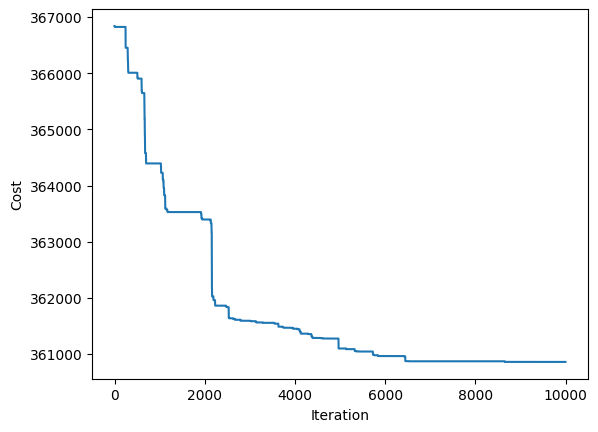

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

history_segment_df = pd.DataFrame(history_segment)

plt.plot(
    history_segment_df["best_cost"]
)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

In [7]:

best_path_segment_df = best_path_segment.to_dataframe()


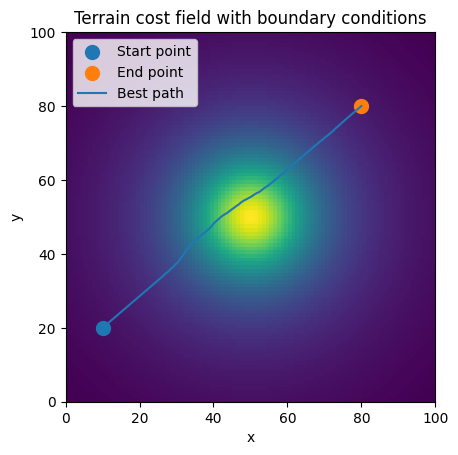

In [8]:

plt.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

plt.scatter(
    boundary.start[0],
    boundary.start[1],
    label="Start point",
    s=100
)

plt.scatter(
    boundary.end[0],
    boundary.end[1],
    label="End point",
    s=100
)

plt.plot( 
    best_path_segment_df["x"],
    best_path_segment_df["y"],
    label="Best path"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Terrain cost field with boundary conditions")

plt.legend()
plt.show()

In [9]:
print(terrain_cost(initial_path, terrain))
print(terrain_curvature_cost(initial_path))
print(terrain_length_cost(initial_path))

print(terrain_cost(best_path_segment, terrain))
print(terrain_curvature_cost(best_path_segment))
print(terrain_length_cost(best_path_segment))

3667.5027231537993
1.555318160733747e-26
92.19544457292892
3607.4895777180336
0.8988543219086873
92.58699704113418


In [10]:
print(best_path_segment_df.to_string(index=False))

 point         x         y
     0 10.000000 20.000000
     1 10.707071 20.606061
     2 11.414141 21.212121
     3 12.121212 21.818182
     4 12.828283 22.424242
     5 13.535354 23.030303
     6 14.242424 23.636364
     7 14.949495 24.242424
     8 15.656566 24.848485
     9 16.363636 25.454545
    10 17.070707 26.060606
    11 17.777778 26.666667
    12 18.484848 27.272727
    13 19.191919 27.878788
    14 19.898990 28.484848
    15 20.606061 29.090909
    16 21.313131 29.696970
    17 22.020202 30.303030
    18 22.727273 30.909091
    19 23.434343 31.515152
    20 24.141414 32.121212
    21 24.848485 32.727273
    22 25.555556 33.333333
    23 26.262626 33.939394
    24 26.969697 34.620724
    25 27.676768 35.152233
    26 28.383838 35.856428
    27 29.090909 36.536705
    28 29.797980 37.266228
    29 30.505051 37.839405
    30 31.212121 38.919361
    31 31.919192 39.868035
    32 32.626263 40.936591
    33 33.333333 41.870658
    34 34.040404 42.620816
    35 34.747475 43.354963
 

In [11]:
print(len(path_history_segment))

1410


Animation for posting and showing Yasemin

In [12]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Reduce frames for LinkedIn
linkedin_history = path_history_segment[::2]


fig, ax = plt.subplots(figsize=(6, 6))

# Plot terrain background
ax.imshow(
    terrain_df,
    extent=[
        0,
        terrain.width,
        0,
        terrain.height
    ],
    origin="lower"
)

# Plot start/end points
ax.scatter(
    boundary.start[0],
    boundary.start[1],
    s=80,
    label="Start"
)

ax.scatter(
    boundary.end[0],
    boundary.end[1],
    s=80,
    label="End"
)

# Empty path line
line, = ax.plot(
    [],
    [],
    linewidth=2,
    label="Optimised path"
)

# Iteration counter
iteration_text = ax.text(
    0.02,
    0.90,
    "",
    transform=ax.transAxes,
    bbox=dict(
        boxstyle="round",
        alpha=0.8
    )
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Simulated Annealing Path Optimisation")

ax.legend()


def update(frame):

    path = linkedin_history[frame]

    points = path.points

    line.set_data(
        points[:, 0],
        points[:, 1]
    )

    # Calculate current path cost
    current_cost = terrain_cost(
        path,
        terrain
    )

    # Recover original iteration number
    iteration_text.set_text(
        f"Iteration: {frame * 2}\n"
        f"Cost: {current_cost:.2f}"
    )

    return line, iteration_text

animation = FuncAnimation(
    fig,
    update,
    frames=len(linkedin_history),
    interval=50,
    blit=True
)


animation.save(
    "/Users/danielskerman/Documents/Masters/Dissertation/msc-calculus-of-variations/numerical/outputs/linkedin_path_rational_quadratic_hill.gif",
    writer="pillow",
    fps=40
)

plt.close()